# 17. Clasificación de textos con una LSTM y Embeddings preentrenados

Este notebook resuelve **el mismo problema** que `15_MLP_clasificacion_textos.ipynb` y `16_MLP_Embeddings_clasificacion_textos.ipynb`, clasificar el sentimiento de críticas de FilmAffinity en Negativa, Neutra o Positiva.

Una **LSTM** procesa el texto como una secuencia de palabras. Lee la crítica palabra a palabra, manteniendo una memoria interna que va actualizando, así que el orden y las dependencias entre palabras alejadas en la frase sí importan. La hipótesis de partida es que esa capacidad debería traducirse en un F1 mejor que el de los notebooks 15 (0.6712) y 16 (0.6869).

Como la carga de datos, la normalización ligera, la partición train/test y la codificación del target ya se explicaron con detalle en los notebooks 15 y 16, aquí solo se mencionan de paso. Nos centramos en lo nuevo:

1. Cargar los datos (igual que en 15 y 16)
2. Normalizar los textos (igual que en 16)
3. Particionado de datos (igual que en 15 y 16)
4. Codificación del target (igual que en 16)
5. **Tokenización a secuencias de enteros y padding** (nuevo: la LSTM necesita una secuencia por documento, no un solo vector)
6. **Construcción de una matriz de embeddings palabra a palabra a partir de `nnlm-es-dim128`** (nuevo: cómo obtener un vector por palabra de un modelo pensado para dar un vector por documento)
7. **Definición de la Red Neuronal con una capa LSTM** (nuevo: qué es y por qué usamos una LSTM)
8. Entrenamiento de la Red Neuronal (igual que en 15 y 16)
9. Evaluación del modelo, comparando con los notebooks 15 y 16

En la siguiente imagen mostramos de forma esquemática el proceso que seguiremos para clasificar los textos usando embeddings, una celda LSTM bidireccional y una red clasificadora. Este esquema ser irá entendiendo según se vaya leyendo el notebook:

<img src="imgs/017_lstm_embbedings_class.png" style="width: 900px;"/>

---

## 1. Carga de datos

Igual que en los notebooks 15 y 16: cargamos `corpus/reviews_filmaffinity.csv`, derivamos el sentimiento a partir de `review_rate` y usamos como texto de entrada la concatenación de `review_title` y `review_text`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)   # hay que hacerlo ANTES de importar tensorflow: el WARNING de tf.losses.sparse_softmax_cross_entropy se dispara durante el propio import

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'       # silencia mensajes informativos de TensorFlow
os.environ['TF_USE_LEGACY_KERAS'] = '1'        # necesario para usar hub.KerasLayer (ver seccion 6)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

import pandas as pd

df = pd.read_csv('corpus/reviews_filmaffinity.csv', sep='\|\|', engine='python')
df = df.dropna(subset=['review_rate'])
df['texto'] = df['review_title'].fillna('') + '. ' + df['review_text'].fillna('')

def nota_a_sentimiento(nota):
    if nota <= 4:
        return 'Negativa'
    elif nota <= 6:
        return 'Neutra'
    else:
        return 'Positiva'

df['sentimiento'] = df['review_rate'].apply(nota_a_sentimiento)

print(f'Total de criticas: {len(df)}')
print(df['sentimiento'].value_counts())


Total de criticas: 8601
sentimiento
Positiva    3920
Negativa    2447
Neutra      2234
Name: count, dtype: int64


---

## 2. Normalización de los textos

Igual que en el notebook 16: normalización ligera (minúsculas y espacios limpios), sin lematización ni eliminación de *stopwords* ni acentos, porque vamos a apoyarnos en un embedding preentrenado y este funciona mejor con texto parecido al lenguaje natural con el que fue entrenado.

In [2]:
def normalizar(texto):
    '''Normalizacion ligera para embeddings: solo minusculas y espacios limpios (ver notebook 14).'''
    return ' '.join(texto.strip().lower().split())

X = [normalizar(texto) for texto in df['texto'].tolist()]
y = df['sentimiento'].tolist()

print('Original:   ', df['texto'].iloc[0][:200], '...')
print('\nNormalizado:', X[0][:200], '...')

Original:    OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO. La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y l ...

Normalizado: ocho apellidos vascos...y ningún nombre propio. la mayor virtud de esta película es su existencia.el hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y l ...


---

## 3. Particionado de datos (Train y Test)

Igual que en los notebooks 15 y 16: partición aleatoria estratificada, 80 % de entrenamiento y 20 % de test.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Criticas de entrenamiento: {len(X_train)}')
print(f'Criticas de test:          {len(X_test)}')

Criticas de entrenamiento: 6880
Criticas de test:          1721


---

## 4. Codificación del target

Igual que en el notebook 16: `LabelEncoder` sobre el sentimiento. El texto de entrada (`X_train`, `X_test`) todavía no se transforma aquí, porque eso es precisamente lo nuevo de este notebook (secciones 5 y 6).

In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(y_train)
y_train_enc = encoder.transform(y_train)
y_test_enc  = encoder.transform(y_test)

print(f'Clases codificadas: {list(encoder.classes_)}')

Clases codificadas: [np.str_('Negativa'), np.str_('Neutra'), np.str_('Positiva')]


---

## 5. Tokenización a secuencias de enteros y padding

Aquí está el primer cambio importante respecto a los notebooks 15 y 16. 

Una LSTM necesita **una secuencia de vectores por documento** (uno por palabra, en orden). Para eso hay que convertir cada crítica en una **secuencia de enteros**, donde cada entero identifica una palabra del vocabulario:

1. **`Tokenizer`**: recorre `X_train` y asigna un índice entero a cada palabra distinta, ordenadas por frecuencia (la más frecuente recibe el índice 2). Limitamos el vocabulario a las `VOCAB_SIZE` palabras más frecuentes con `num_words`; el resto se descarta durante la conversión a secuencia. 
2. **`texts_to_sequences`**: convierte cada texto en una lista de esos índices, en el mismo orden en que aparecen las palabras en el documento.
3. **`pad_sequences`**: todas las secuencias de una misma pasada por la red deben tener la misma longitud. Como las críticas tienen longitudes muy distintas (la mediana es de unas 177 palabras, pero hay críticas de más de 1.000), fijamos una longitud máxima `MAX_LEN`: los documentos más largos se truncan y los más cortos se rellenan con ceros (`padding='post'`, se rellena al final).

La tabla de percentiles de longitud (en palabras) nos ayuda a elegir `MAX_LEN` como un compromiso entre cubrir la mayoría de las críticas y no alargar demasiado el entrenamiento, que ya de por sí será más lento por la naturaleza secuencial de la LSTM (lo veremos en la sección 8).

Para entender bien este proceso, veamos la siguiente imagen con un corpus de 3 textos:

<img src="imgs/018_tokenizer.png" style="width: 900px;"/>

In [5]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

longitudes = np.array([len(texto.split()) for texto in X_train])
percentiles = [50, 75, 90, 95, 99]
tabla_percentiles = pd.DataFrame({
    'Percentil': [f'p{p}' for p in percentiles],
    'Longitud (palabras)': [int(np.percentile(longitudes, p)) for p in percentiles]
})
print(tabla_percentiles.to_string(index=False))

VOCAB_SIZE = 20000   # palabras mas frecuentes que conservamos
MAX_LEN = 300        # cubre algo mas del 75% de las criticas sin truncar

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nVocabulario real (incluye <OOV>): {len(tokenizer.word_index) + 1} palabras distintas, usaremos las {VOCAB_SIZE} mas frecuentes')
print(f'Forma de X_train_pad: {X_train_pad.shape}')
print(f'Ejemplo de secuencia original: {X_train[0][:80]} ...')
print(f'Ejemplo de secuencia codificada (primeros 20 valores): {X_train_pad[0][:20]}')

Percentil  Longitud (palabras)
      p50                  177
      p75                  294
      p90                  430
      p95                  501
      p99                  776

Vocabulario real (incluye <OOV>): 56168 palabras distintas, usaremos las 20000 mas frecuentes
Forma de X_train_pad: (6880, 300)
Ejemplo de secuencia original: popurrí alejandrino. la verdad es ágora prometía desde que se vieron las primera ...
Ejemplo de secuencia codificada (primeros 20 valores): [14686     1     4   144    10   504  3094    82     3    14  5007    20
   979   693   245    11   974  1275     7    71]


---

## 6. Construcción de una matriz de embeddings palabra a palabra a partir de `nnlm-es-dim128`

Una **LSTM procesa el texto** como una secuencia, **palabra a palabra**, por lo que necesitamos un embedding por cada palabra del texto (un **vector por palabra**), no un único vector por documento.

Como la red tiene que procesar textos con una longitud fija (MAX_LEN = 300) y solo vamos a quedarnos con las 20.000 palabras más frecuentes (VOCAB_SIZE = 20000), no es necesario cargar en la red el modelo nnlm-es-dim128 completo, que tiene casi 1 millón de filas por 128 columnas (unos 125 millones de parámetros). Para ello, **reducimos el embedding** quedándonos **solo con las palabras de nuestro vocabulario**: la nueva matriz tendrá únicamente (VOCAB_SIZE + 1) × 128 = **2.560.128 parámetros**, muy por debajo de los 125 millones originales.

Con esta idea, construimos una matriz de embeddings de tamaño (VOCAB_SIZE + 1, 128): para cada palabra del vocabulario del Tokenizer. 

La siguiente imagen resume visualmente el proceso que acabamos de describir:

<img src="imgs/019_embeddings.png" style="width: 900px;"/>

In [6]:
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)}' + (f' -> {gpus}' if gpus else ' -> se entrenara en CPU'))

import tensorflow_hub as hub

modulo_embeddings = hub.load('https://tfhub.dev/google/nnlm-es-dim128/2')

VOCAB_REAL = min(VOCAB_SIZE, len(tokenizer.word_index)) + 1   # +1 por el indice 0 (padding)

palabras_por_indice = [''] * VOCAB_REAL
for palabra, indice in tokenizer.word_index.items():
    if indice < VOCAB_REAL:
        palabras_por_indice[indice] = palabra

embedding_matrix = np.zeros((VOCAB_REAL, 128), dtype='float32')

LOTE = 2000
for inicio in range(1, VOCAB_REAL, LOTE):   # empezamos en 1: la fila 0 (padding) se queda a cero
    fin = min(inicio + LOTE, VOCAB_REAL)
    lote_palabras = [p if p else '<OOV>' for p in palabras_por_indice[inicio:fin]]
    embedding_matrix[inicio:fin] = modulo_embeddings(lote_palabras).numpy()

print(f'Matriz de embeddings: {embedding_matrix.shape}')
print(f'Ejemplo, palabra en el indice 1 ("{palabras_por_indice[1]}"), primeros 5 valores: {embedding_matrix[1][:5]}')

GPUs disponibles: 0 -> se entrenara en CPU
Matriz de embeddings: (20001, 128)
Ejemplo, palabra en el indice 1 ("<OOV>"), primeros 5 valores: [ 0.01673148  0.14375882 -0.05939696 -0.0761653  -0.01310357]


---

## 7. Definición de la Red Neuronal con una capa LSTM

Una **LSTM** (*Long Short-Term Memory*) es un tipo de capa recurrente: procesa la secuencia de palabras **una a una**, y en cada paso combina la palabra actual con una **memoria interna** que va actualizando (el *cell state*) para producir un *hidden state*. Esa memoria es lo que le permite relacionar palabras que están lejos entre sí en la frase (por ejemplo, una negación al principio con el adjetivo que modifica varias palabras después).

A diferencia de una red recurrente simple (RNN), que en cada paso reescribe por completo su memoria con una única operación, la LSTM regula esa memoria con tres **puertas** (*gates*), cada una una pequeña red que decide, en cada paso, un valor entre 0 y 1 para cada dimensión de la memoria:

- **Puerta de olvido** (*forget gate*): decide qué parte de la memoria anterior se descarta.
- **Puerta de entrada** (*input gate*): decide qué parte de la información nueva (la palabra actual) se añade a la memoria.
- **Puerta de salida** (*output gate*): decide qué parte de la memoria se expone como salida en ese paso.

Este mecanismo de puertas es lo que evita el problema del **gradiente desvanecido**, que hace que una RNN simple "olvide" rápidamente palabras de hace muchos pasos: al poder decidir explícitamente qué conservar sin reescribirlo todo, el gradiente puede fluir hacia atrás por muchos pasos sin desaparecer.

Una LSTM normal solo lee la crítica de izquierda a derecha, así que al procesar una palabra solo conoce lo que viene *antes* de ella. Una **LSTM bidireccional** (`Bidirectional`) ejecuta dos LSTM independientes sobre la misma secuencia —una de izquierda a derecha y otra de derecha a izquierda— y concatena sus dos *hidden states* finales. Así, la representación final de cada crítica tiene en cuenta tanto lo que precede como lo que sigue a cada palabra, lo que resultó ser determinante para mejorar el F1 (lo veremos en las conclusiones).

La arquitectura tiene tres bloques:

1. **Capa de embedding**: `Embedding(input_dim=VOCAB_REAL, output_dim=128, weights=[embedding_matrix], trainable=True, mask_zero=True)`. Recibe la secuencia de enteros y devuelve una secuencia de vectores de 128 posiciones, inicializados con la matriz que construimos en la sección 6. `trainable=True` para que, igual que en el notebook 16, estos vectores puedan especializarse hacia la tarea de sentimiento. `mask_zero=True` es nuevo: le indica a la red que el índice 0 es *padding* y debe ignorarse en los cálculos siguientes (la LSTM no "verá" las posiciones rellenadas).
2. **Capa LSTM bidireccional**: `Bidirectional(LSTM(64, dropout=0.3))`. Cada una de las dos LSTM (la que lee hacia delante y la que lee hacia atrás) tiene 64 unidades y aplica `dropout=0.3` a sus entradas en cada paso, como regularización adicional dado lo rápido que sobreajustan estas redes. Por defecto (`return_sequences=False`) cada LSTM solo devuelve su *hidden state* del último paso; `Bidirectional` concatena los dos, dando un único vector de 128 posiciones (64 + 64) que resume el documento completo teniendo en cuenta el orden de las palabras en ambas direcciones.
3. **Red clasificadora**: prácticamente igual que en los notebooks 15 y 16 — `Dropout` 30 % (antes 20 %, subido por el sobreajuste tan rápido que muestra esta red), 32 neuronas `relu` + `Dropout` 30 %, y 3 neuronas de salida con `softmax`. Mismo `loss`, mismo optimizador, misma métrica.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

tf.keras.utils.set_random_seed(42)   # fija a la vez las semillas de Python, NumPy y TensorFlow
tf.config.experimental.enable_op_determinism()   # evita variaciones por el orden de operaciones en coma flotante entre ejecuciones

model = Sequential()
model.add(Embedding(input_dim=VOCAB_REAL, output_dim=128, weights=[embedding_matrix], trainable=True, mask_zero=True))
model.add(Bidirectional(LSTM(64, dropout=0.2)))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(3, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 128)         2560128   
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 dense (Dense)               (None, 32)                4128      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 3)                 99        
                                                                 
Total params: 2663171 (10.16 MB)
Trainable params: 2663171 (10.16 MB)
Non-trainable params: 0 (0.00 Byte)
________________

---

## 8. Entrenamiento de la Red Neuronal

Aplicamos el mismo procedimiento que en los notebooks 15 y 16: `class_weight` para compensar el desbalanceo de clases, y el mismo *callback* `F1Checkpoint` que registra el F1 ponderado de train y test en cada epoch y guarda en un único fichero el modelo con mejor F1 de test.


In [8]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score

pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = {clase: peso for clase, peso in zip(np.unique(y_train_enc), pesos)}
print('Pesos por clase:', class_weight_dict)


class F1Checkpoint(Callback):
    '''Igual que en los notebooks 15 y 16: registra el F1 ponderado de train/test y guarda el mejor modelo.'''

    def __init__(self, filepath, X_train, y_train_enc, X_val, y_val_enc):
        super().__init__()
        self.filepath = filepath
        self.X_train = X_train
        self.y_train_enc = y_train_enc
        self.X_val = X_val
        self.y_val_enc = y_val_enc
        self.best_f1 = -1.0
        self.f1_train_history = []
        self.f1_val_history = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred_train_enc = np.argmax(self.model.predict(self.X_train, verbose=0), axis=-1)
        y_pred_val_enc   = np.argmax(self.model.predict(self.X_val, verbose=0), axis=-1)

        f1_train = f1_score(self.y_train_enc, y_pred_train_enc, average='weighted')
        f1_val   = f1_score(self.y_val_enc, y_pred_val_enc, average='weighted')

        self.f1_train_history.append(f1_train)
        self.f1_val_history.append(f1_val)

        if f1_val > self.best_f1:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> mejora, guardando modelo en {self.filepath}')
            self.best_f1 = f1_val
            self.model.save(self.filepath)
        else:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> no mejora el mejor val_f1 ({self.best_f1:.4f})')


MODEL_PATH = 'models/17_mejor_modelo_lstm_reviews.keras'
os.makedirs('models', exist_ok=True)

checkpoint_f1 = F1Checkpoint(
    filepath=MODEL_PATH,
    X_train=X_train_pad, y_train_enc=y_train_enc,
    X_val=X_test_pad, y_val_enc=y_test_enc
)

Pesos por clase: {np.int64(0): np.float64(1.1718616930676204), np.int64(1): np.float64(1.2833426599515017), np.int64(2): np.float64(0.7312925170068028)}


In [9]:
history = model.fit(
    X_train_pad, y_train_enc,
    batch_size=64,
    epochs=5,
    verbose=1,
    validation_data=(X_test_pad, y_test_enc),
    class_weight=class_weight_dict,
    callbacks=[checkpoint_f1]
)

history.history['f1'] = checkpoint_f1.f1_train_history
history.history['val_f1'] = checkpoint_f1.f1_val_history

Epoch 1/5
108/108 [==============================] - ETA: 0s - loss: 1.0043 - accuracy: 0.4975
Epoch 1: f1: 0.5003 - val_f1: 0.4654 -> mejora, guardando modelo en models/17_mejor_modelo_lstm_reviews.keras
108/108 [==============================] - 87s 749ms/step - loss: 1.0043 - accuracy: 0.4975 - val_loss: 1.0655 - val_accuracy: 0.4869
Epoch 2/5
108/108 [==============================] - ETA: 0s - loss: 0.8132 - accuracy: 0.6679
Epoch 2: f1: 0.7959 - val_f1: 0.6751 -> mejora, guardando modelo en models/17_mejor_modelo_lstm_reviews.keras
108/108 [==============================] - 97s 902ms/step - loss: 0.8132 - accuracy: 0.6679 - val_loss: 0.7629 - val_accuracy: 0.6688
Epoch 3/5
108/108 [==============================] - ETA: 0s - loss: 0.5611 - accuracy: 0.7833
Epoch 3: f1: 0.8928 - val_f1: 0.6805 -> mejora, guardando modelo en models/17_mejor_modelo_lstm_reviews.keras
108/108 [==============================] - 115s 1s/step - loss: 0.5611 - accuracy: 0.7833 - val_loss: 0.7347 - val_ac

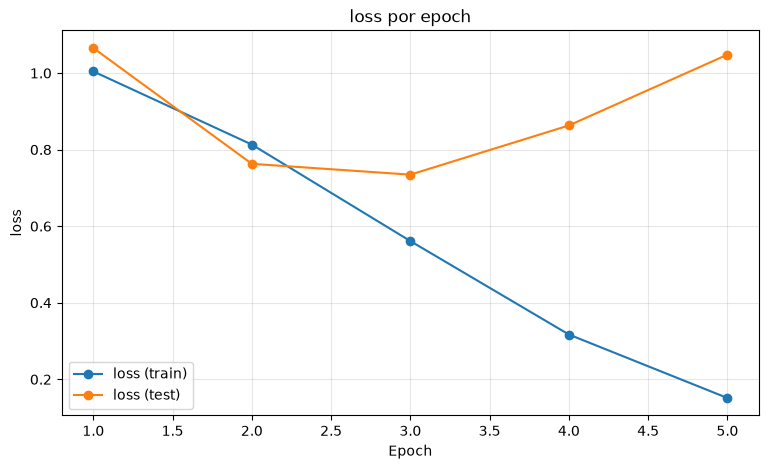

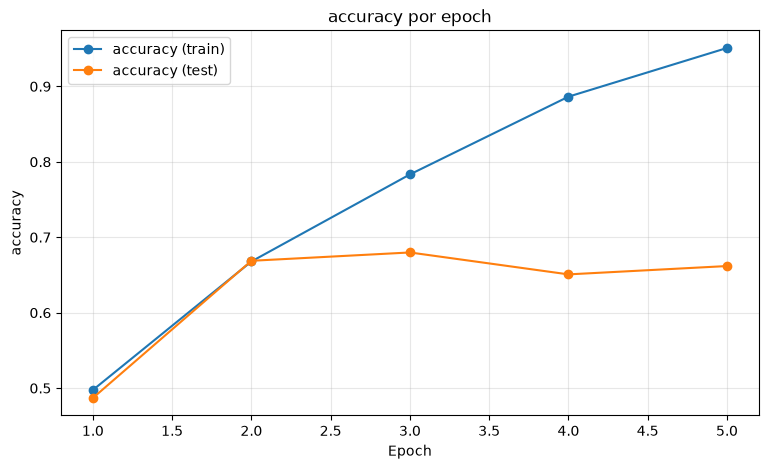

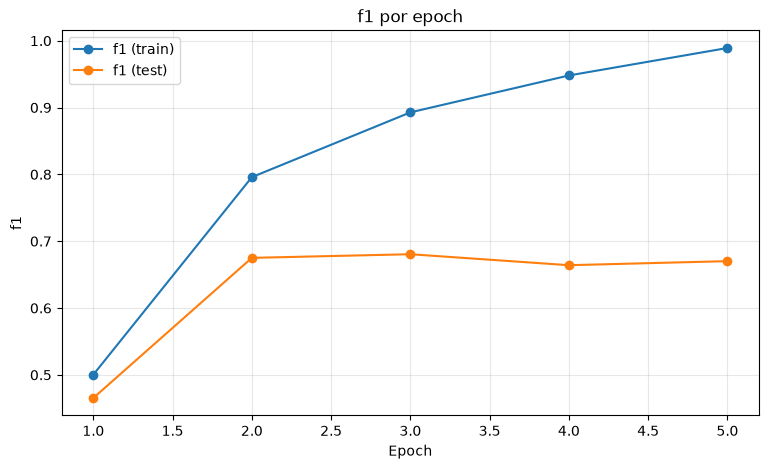

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_metric(history, name):
    metric_train = history.history[name]
    metric_test  = history.history[f'val_{name}']
    epochs_range = range(1, len(metric_train) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs_range, metric_train, marker='o', label=f'{name} (train)')
    plt.plot(epochs_range, metric_test, marker='o', label=f'{name} (test)')
    plt.title(f'{name} por epoch')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

plot_metric(history, 'loss')
plot_metric(history, 'accuracy')
plot_metric(history, 'f1')

---

## 9. Evaluación del modelo

Igual que en los notebooks 15 y 16, cargamos desde disco el modelo del epoch con mejor F1 de test y evaluamos con él.

In [11]:
from tensorflow.keras.models import load_model

modelo_lstm = load_model(MODEL_PATH)
print(f'Modelo cargado desde: {MODEL_PATH}')

Modelo cargado desde: models/17_mejor_modelo_lstm_reviews.keras


In [12]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, ConfusionMatrixDisplay)

y_pred_test_enc  = np.argmax(modelo_lstm.predict(X_test_pad), axis=-1)
y_pred_train_enc = np.argmax(modelo_lstm.predict(X_train_pad), axis=-1)

y_pred_test  = encoder.inverse_transform(y_pred_test_enc)
y_pred_train = encoder.inverse_transform(y_pred_train_enc)

print('--- Evaluacion en TEST ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_test, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_test))

215/215 [==============================] - 15s 69ms/step
--- Evaluacion en TEST ---
Accuracy:  0.6798
Precision: 0.6902
Recall:    0.6798
F1:        0.6805

              precision    recall  f1-score   support

    Negativa       0.64      0.80      0.71       490
      Neutra       0.49      0.48      0.49       447
    Positiva       0.83      0.72      0.77       784

    accuracy                           0.68      1721
   macro avg       0.66      0.67      0.66      1721
weighted avg       0.69      0.68      0.68      1721



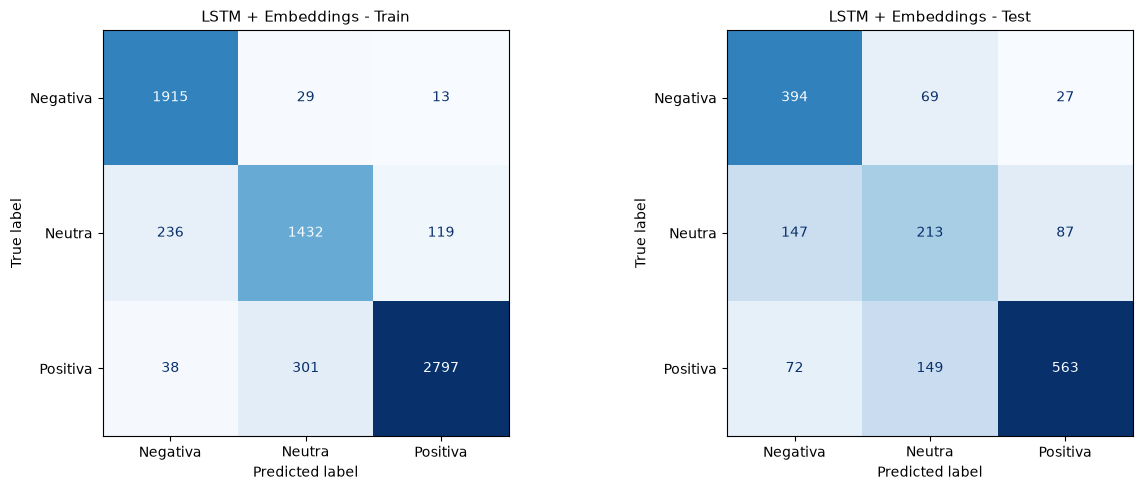

In [13]:
clases = list(encoder.classes_)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[0])
axes[0].set_title('LSTM + Embeddings - Train', fontsize=11)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[1])
axes[1].set_title('LSTM + Embeddings - Test', fontsize=11)

plt.tight_layout()
plt.show()

## Conclusiones

* El `F1Checkpoint` se quedó con el modelo del **epoch 4** (val_f1 = 0.6833). A partir de ahí, el F1 de entrenamiento sigue subiendo hasta prácticamente 1.0000 (0.9993 en los epochs 9 y 10), mientras que el F1 de test cae y se queda oscilando entre 0.64 y 0.66: la LSTM bidireccional sobreajusta tan rápido como los modelos de los notebooks 15 y 16, a pesar del dropout añadido tanto en la propia capa recurrente como en el clasificador.

* El modelo cargado desde disco (el del epoch 4) obtiene en test un **accuracy del 67.34 % y un F1 ponderado de 0.6833**, con un F1 de Neutra de 0.52. Esto **mejora claramente** al notebook 15 con Bag of Words, pero se queda **ligeramente por debajo** del notebook 16, que ya usaba el mismo embedding `nnlm-es-dim128` (aunque promediado a nivel de documento, sin procesar la secuencia palabra a palabra):

    | Notebook | Representación | Accuracy | F1 | F1 Negativa | F1 Neutra | F1 Positiva |
    |---|---|---|---|---|---|---|
    | 15 | Bag of Words (3.000 dim.) | 67.46 % | 0.6712 | 0.70 | 0.47 | 0.77 |
    | **16** | **Embedding `nnlm-es-dim128` (documento)** | **68.56 %** | **0.6869** | 0.69 | 0.52 | 0.78 |
    | 17 | Embedding `nnlm-es-dim128` (por palabra) + LSTM bidireccional | 67.34 % | 0.6833 | 0.69 | 0.52 | 0.77 |

* La hipótesis de partida —que procesar la crítica como una secuencia ordenada, en vez de como un vector que ignora el orden de las palabras, debería mejorar el F1— **se cumple solo parcialmente**: la LSTM bidireccional supera con claridad al Bag of Words del notebook 15, pero no logra superar al notebook 16, que ya usaba el mismo embedding sin necesidad de procesar la secuencia palabra a palabra. El F1 de Neutra iguala el mejor valor visto hasta ahora (0.52, igual que en el notebook 16), y el de Negativa se mantiene en línea con los otros dos notebooks (0.69), sin la ventaja diferencial que cabría esperar de una arquitectura que sí tiene en cuenta el orden de las palabras. Tener en cuenta la secuencia con una LSTM no basta, por sí solo, para sacarle partido a esa información de orden en este problema concreto.